### a) Ler o dataset fakeTelegram.BR_2022.csv, o qual está disponível no link a seguir: https://drive.google.com/file/d/1c_hLzk85pYw-huHSnFYZM_gndUsYRDm/view?usp=drive_link

In [4]:
import pandas as pd

# Define o nome do arquivo a ser lido
file_path = 'fakeTelegram.BR_2022.short.csv'

df = pd.read_csv(file_path)

### b) Remova os trava-zaps, as linhas repetidas (duplicadas) e textos com menos de 5 palavras.

In [5]:
print("Removendo trava-zaps...")
df_limpo = df[df['trava_zap'] == False].copy()
print(f"Formato após remover trava-zaps: {df_limpo.shape}")

print("Removendo mensagens duplicadas (baseado no conteúdo do texto)...")
df_limpo.drop_duplicates(subset=['text_content_anonymous'], inplace=True)
print(f"Formato após remover duplicatas: {df_limpo.shape}")

print("Removendo mensagens com menos de 5 palavras...")
condicao_palavras = (df_limpo['text_content_anonymous'].isna()) | (df_limpo['text_content_anonymous'].str.split().str.len() >= 5)
df_limpo = df_limpo[condicao_palavras]

df_limpo.head()


Removendo trava-zaps...
Formato após remover trava-zaps: (131, 19)
Removendo mensagens duplicadas (baseado no conteúdo do texto)...
Formato após remover duplicatas: (78, 19)
Removendo mensagens com menos de 5 palavras...


,date_message,id_member_anonymous,id_group_anonymous,media,media_type,media_url,has_media,has_media_url,trava_zap,text_content_anonymous,dataset_info_id,date_system,score_sentiment,score_misinformation,id_message,message_type,messenger,media_name,media_md5
0,2022-10-05 06:25:04,1078cc958f0febe28f4d03207660715f,12283e08a2eb5789201e105b34489ee7,NaN,NaN,NaN,False,False,False,Então é Fato Renato o áudio que eu ouvi no wha...,5,2022-10-05 06:25:28.863641,0.0000,NaN,16385,Texto,telegram,NaN,NaN
1,2022-10-05 06:25:08,NaN,12283e08a2eb5789201e105b34489ee7,NaN,NaN,NaN,False,False,False,"Saiu no YouTube do presidente a 8 horas atrás,...",5,2022-10-05 06:25:28.926311,0.0644,NaN,16386,Texto,telegram,NaN,NaN
2,2022-10-05 06:26:28,92a2d8fd7144074f659d1d29dc3751da,9f2d7394334eb224c061c9740b5748fc,NaN,NaN,NaN,False,False,False,"É isso, nossa parte já foi quase toda feita. N...",5,2022-10-05 06:26:29.361949,-0.3551,0.157242,16366,Texto,telegram,NaN,NaN
3,2022-10-05 06:27:28,d60aa38f62b4977426b70944af4aff72,c8f2de56550ed0bf85249608b7ead93d,94dca4cda503100ebfda7ce2bcc060eb.jpg,image/jpg,NaN,True,False,False,GENTE ACHEI ELES EM UMA SEITA MAÇONÁRICA,5,2022-10-05 06:27:29.935624,0.0000,NaN,19281,Imagem,telegram,NaN,94dca4cda503100ebfda7ce2bcc060eb
4,2022-10-05 06:27:44,cd6979b0b5265f08468fa1689b6300ce,e56ec342fc599ebb4ed89655eb6f03aa,5ad5c8bbe9da93a37fecf3e5aa5b0637.jpg,image/jpg,NaN,True,False,False,NaN,5,2022-10-05 06:28:29.316325,NaN,NaN,507185,Imagem,telegram,NaN,5ad5c8bbe9da93a37fecf3e5aa5b0637


### c) Agrupe as linhas com postagens iguais ou extremamente semelhantes. Aqui você pode utilizar uma métrica de semelhança de textos. Crie uma variável para representar a quantidade de vezes que a mensagem foi compartilhada. Observe que ao agrupar linhas que possuem a “mesma” postagem (texto), você deve escolher como valor para as variáveis data e hora da postagem, os valores da cópia mais antiga. 


In [7]:
from thefuzz import process, fuzz
import pandas as pd

df_limpo['date_message'] = pd.to_datetime(df_limpo['date_message'])

df_limpo['text_content_anonymous'] = df_limpo['text_content_anonymous'].fillna('')

df_to_process = df_limpo.copy()

SIMILARITY_THRESHOLD = 90


clusters = []
processed_indices = set()
choices_dict = df_to_process['text_content_anonymous'].to_dict()

print(f"Iniciando o agrupamento por similaridade para {len(df_to_process)} mensagens...")

for index, row in df_to_process.iterrows():
    if index in processed_indices:
        continue

    query_text = row['text_content_anonymous']
    
    similar_texts = process.extractBests(
        query_text, 
        choices_dict, 
        scorer=fuzz.ratio, 
        score_cutoff=SIMILARITY_THRESHOLD,
        limit=None
    )

    current_cluster_indices = [idx for text, score, idx in similar_texts]
    if current_cluster_indices:
        clusters.append(current_cluster_indices)
        processed_indices.update(current_cluster_indices)

print(f"Agrupamento concluído. Encontrados {len(clusters)} grupos de mensagens únicas/similares.")

final_rows = []

for cluster_indices in clusters:
   
    cluster_df = df_to_process.loc[cluster_indices]
    oldest_index = cluster_df['date_message'].idxmin()
    representative_row = cluster_df.loc[oldest_index].copy()
    representative_row['share_count'] = len(cluster_df)
    final_rows.append(representative_row)
df_agrupado = pd.DataFrame(final_rows)
df_agrupado = df_agrupado.sort_values('date_message').reset_index(drop=True)


print("\n--- DataFrame Final Agrupado ---")
display_cols = ['date_message', 'share_count', 'text_content_anonymous']
print(df_agrupado[display_cols].head())
print("\nExemplo de mensagens que foram agrupadas (com contagem de compartilhamento > 1):")
print(df_agrupado[df_agrupado['share_count'] > 1][display_cols])

Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '']


Iniciando o agrupamento por similaridade para 72 mensagens...
Agrupamento concluído. Encontrados 69 grupos de mensagens únicas/similares.

--- DataFrame Final Agrupado ---
         date_message  share_count  \
0 2022-10-05 06:25:04            1   
1 2022-10-05 06:25:08            1   
2 2022-10-05 06:26:28            1   
3 2022-10-05 06:27:28            1   
4 2022-10-05 06:27:44            1   

                              text_content_anonymous  
0  Então é Fato Renato o áudio que eu ouvi no wha...  
1  Saiu no YouTube do presidente a 8 horas atrás,...  
2  É isso, nossa parte já foi quase toda feita. N...  
3           GENTE ACHEI ELES EM UMA SEITA MAÇONÁRICA  
4                                                     

Exemplo de mensagens que foram agrupadas (com contagem de compartilhamento > 1):
          date_message  share_count  \
7  2022-10-05 06:29:48            3   
14 2022-10-05 06:43:51            2   

                               text_content_anonymous  
7   O Deputad

### d) Você pode criar novos atributos numéricos, tais como: quantidade de palavras, quantidade de caracteres etc. 


In [8]:
import string 

print("Criando novos atributos numéricos a partir do texto...")

# 1. Quantidade de Caracteres: O tamanho total da string.
df_agrupado['char_count'] = df_agrupado['text_content_anonymous'].str.len()

# 2. Quantidade de Palavras: Divide o texto por espaços e conta o número de elementos.
df_agrupado['word_count'] = df_agrupado['text_content_anonymous'].str.split().str.len().fillna(0).astype(int)

# 3. Comprimento Médio da Palavra: Pode indicar a complexidade do vocabulário.
df_agrupado['avg_word_length'] = df_agrupado['char_count'] / df_agrupado['word_count']
df_agrupado['avg_word_length'].fillna(0, inplace=True)

# 4. Contagem de Pontuação: Conta o número de caracteres de pontuação.
df_agrupado['punctuation_count'] = df_agrupado['text_content_anonymous'].apply(
    lambda text: sum(1 for char in text if char in string.punctuation)
)

# 5. Proporção de Letras Maiúsculas: Indica ênfase ou "grito".
df_agrupado['uppercase_ratio'] = df_agrupado['text_content_anonymous'].apply(
    lambda text: sum(1 for char in text if char.isupper()) / len(text) if len(text) > 0 else 0
)

print("Novos atributos criados com sucesso!")

display_cols = [
    'text_content_anonymous',
    'share_count',
    'char_count',
    'word_count',
    'avg_word_length',
    'punctuation_count',
    'uppercase_ratio'
]

print("\n--- DataFrame com Novos Atributos ---")
print(df_agrupado[display_cols].head())
print("\n--- Estatísticas Descritivas dos Novos Atributos ---")
print(df_agrupado[display_cols[2:]].describe())

Criando novos atributos numéricos a partir do texto...
Novos atributos criados com sucesso!

--- DataFrame com Novos Atributos ---
                              text_content_anonymous  share_count  char_count  \
0  Então é Fato Renato o áudio que eu ouvi no wha...            1         110   
1  Saiu no YouTube do presidente a 8 horas atrás,...            1         141   
2  É isso, nossa parte já foi quase toda feita. N...            1         350   
3           GENTE ACHEI ELES EM UMA SEITA MAÇONÁRICA            1          40   
4                                                               1           0   

   word_count  avg_word_length  punctuation_count  uppercase_ratio  
0          20         5.500000                  1         0.045455  
1          23         6.130435                  2         0.035461  
2          59         5.932203                  9         0.017143  
3           7         5.714286                  0         0.850000  
4           0         0.000000       

C:\Users\wj070\AppData\Local\Temp\ipykernel_13360\1034777468.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_agrupado['avg_word_length'].fillna(0, inplace=True)


### Questão 1 


In [10]:
# Importações e setup
import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.sparse import hstack
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

nltk.download('stopwords')
nltk.download('rslp')

stop_words_pt = set(stopwords.words('portuguese'))
stemmer_pt = RSLPStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wj070\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\wj070\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


### Configuração do experimento

In [13]:
# Setup do experimento
NUMERICAL_FEATURES = ['char_count', 'word_count', 'avg_word_length', 'punctuation_count', 'uppercase_ratio']
TEXT_FEATURE = 'text_content_anonymous'

X = df_agrupado[NUMERICAL_FEATURES + [TEXT_FEATURE]]
y = df_agrupado['virality_level']

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []

MODELS_TO_TEST = {
    'LogisticRegression_NoReg': OneVsRestClassifier(LogisticRegression(penalty=None, max_iter=1000)),
    'LogisticRegression_L1': OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=1.0)),
    'LogisticRegression_L2': OneVsRestClassifier(LogisticRegression(penalty='l2', C=1.0, max_iter=1000)),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42)
}

SCALERS_TO_TEST = {
    'NoScaler': None,
    'Z-Score': StandardScaler(with_mean=False),
    'MinMax': MinMaxScaler()
}

PREPROCESSING_TO_TEST = {
    'Sem_Preprocessamento': False,
    'Com_Preprocessamento': True
}

EMBEDDINGS_TO_TEST = {
    'BOW_Unigram': ('bow', (1, 1)),
    'BOW_Bigram': ('bow', (1, 2)),
    'BOW_Trigram': ('bow', (1, 3)),
    'TFIDF_Unigram': ('tfidf', (1, 1)),
    'TFIDF_Bigram': ('tfidf', (1, 2)),
    'TFIDF_Trigram': ('tfidf', (1, 3))
}

### Definição da variável-alvo

In [12]:
# Definindo alvo multiclasse a partir dos quartis
try:
    df_agrupado['virality_level'] = pd.qcut(df_agrupado['share_count'], q=4, labels=False, duplicates='drop')
except ValueError:
    df_agrupado['virality_level'] = pd.qcut(df_agrupado['share_count'], q=3, labels=False, duplicates='drop')

df_agrupado.dropna(subset=['virality_level'], inplace=True)
df_agrupado['virality_level'] = df_agrupado['virality_level'].astype(int)

### Pré-processamento textual

In [ ]:
# Pré-processamento de texto
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = [word for word in text.split() if word not in stop_words_pt]
    stemmed_tokens = [stemmer_pt.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)

### Execução do experimento

In [15]:
# Loop de experimentos com Outer K-Fold
import warnings
warnings.filterwarnings("ignore")
total_runs = len(MODELS_TO_TEST) * len(SCALERS_TO_TEST) * len(PREPROCESSING_TO_TEST) * len(EMBEDDINGS_TO_TEST)
run_count = 0

for model_name, model in MODELS_TO_TEST.items():
    for scaler_name, scaler in SCALERS_TO_TEST.items():
        for preproc_name, use_preprocessing in PREPROCESSING_TO_TEST.items():
            for embed_name, (embed_type, ngram_range) in EMBEDDINGS_TO_TEST.items():
                run_count += 1
                fold_scores = []

                for train_idx, test_idx in outer_cv.split(X, y):
                    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                    X_train_text = X_train[TEXT_FEATURE].apply(preprocess_text) if use_preprocessing else X_train[TEXT_FEATURE]
                    X_test_text = X_test[TEXT_FEATURE].apply(preprocess_text) if use_preprocessing else X_test[TEXT_FEATURE]

                    vectorizer = CountVectorizer(ngram_range=ngram_range) if embed_type == 'bow' else TfidfVectorizer(ngram_range=ngram_range)
                    X_train_text_feat = vectorizer.fit_transform(X_train_text)
                    X_test_text_feat = vectorizer.transform(X_test_text)

                    X_train_num_feat = X_train[NUMERICAL_FEATURES].values
                    X_test_num_feat = X_test[NUMERICAL_FEATURES].values
                    if scaler:
                        X_train_num_feat = scaler.fit_transform(X_train_num_feat)
                        X_test_num_feat = scaler.transform(X_test_num_feat)

                    X_train_final = hstack([X_train_text_feat, X_train_num_feat]).tocsr()
                    X_test_final = hstack([X_test_text_feat, X_test_num_feat]).tocsr()

                    model.fit(X_train_final, y_train)
                    y_pred = model.predict(X_test_final)

                    fold_scores.append({
                        'accuracy': accuracy_score(y_test, y_pred),
                        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
                        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
                        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
                    })

                avg_scores = pd.DataFrame(fold_scores).mean().to_dict()
                results_list.append({
                    'Modelo': model_name,
                    'Normalizador': scaler_name,
                    'Preprocessamento': preproc_name,
                    'Embedding_Ngram': embed_name,
                    'F1_Macro': avg_scores['f1_macro'],
                    'Precisao_Macro': avg_scores['precision_macro'],
                    'Recall_Macro': avg_scores['recall_macro'],
                    'Acuracia_Media': avg_scores['accuracy']
                })

### Análise e visualização dos resultados


🏆 Melhor modelo: RandomForest
Embedding: TFIDF_Trigram
Preprocessamento: Com_Preprocessamento
Normalização: MinMax
F1-Score (Macro): 1.0000
Acurácia Média: 1.0000


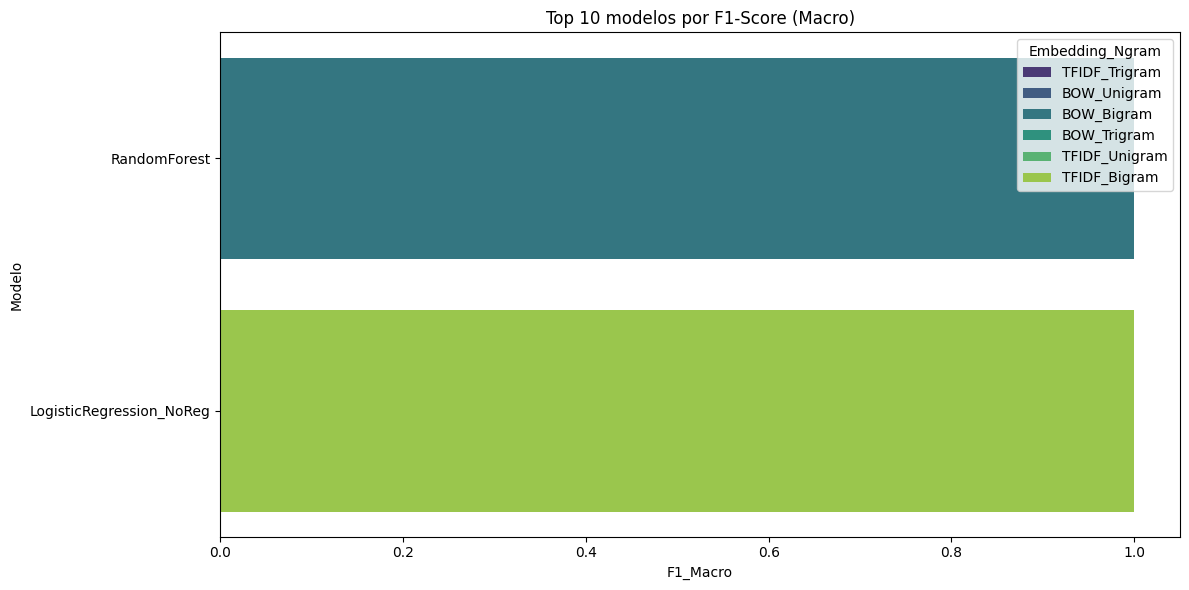

In [16]:
# Análise e visualização dos resultados
results_df = pd.DataFrame(results_list)
results_df_sorted = results_df.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

melhor_resultado = results_df_sorted.iloc[0]
print(f"\n🏆 Melhor modelo: {melhor_resultado['Modelo']}")
print(f"Embedding: {melhor_resultado['Embedding_Ngram']}")
print(f"Preprocessamento: {melhor_resultado['Preprocessamento']}")
print(f"Normalização: {melhor_resultado['Normalizador']}")
print(f"F1-Score (Macro): {melhor_resultado['F1_Macro']:.4f}")
print(f"Acurácia Média: {melhor_resultado['Acuracia_Media']:.4f}")

results_df_sorted.to_csv("resultados_classificacao_viralidade.csv", index=False)

# Gráfico: F1-Score
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_sorted.head(10),
    x='F1_Macro',
    y='Modelo',
    hue='Embedding_Ngram',
    dodge=False,
    palette='viridis'
)
plt.title('Top 10 modelos por F1-Score (Macro)')
plt.tight_layout()
plt.show()

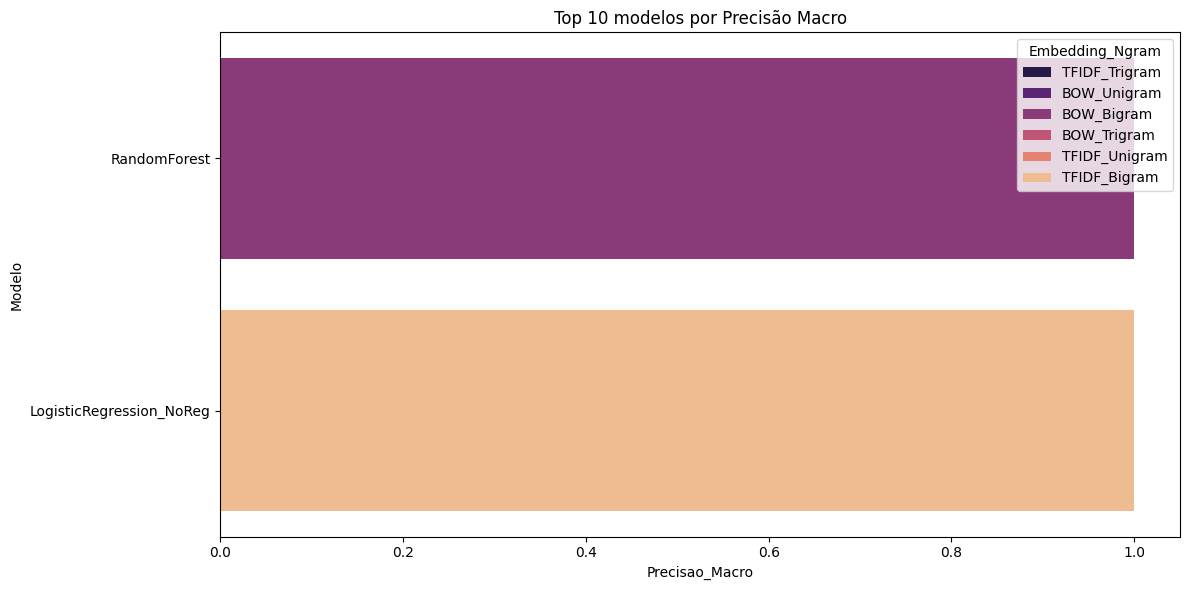

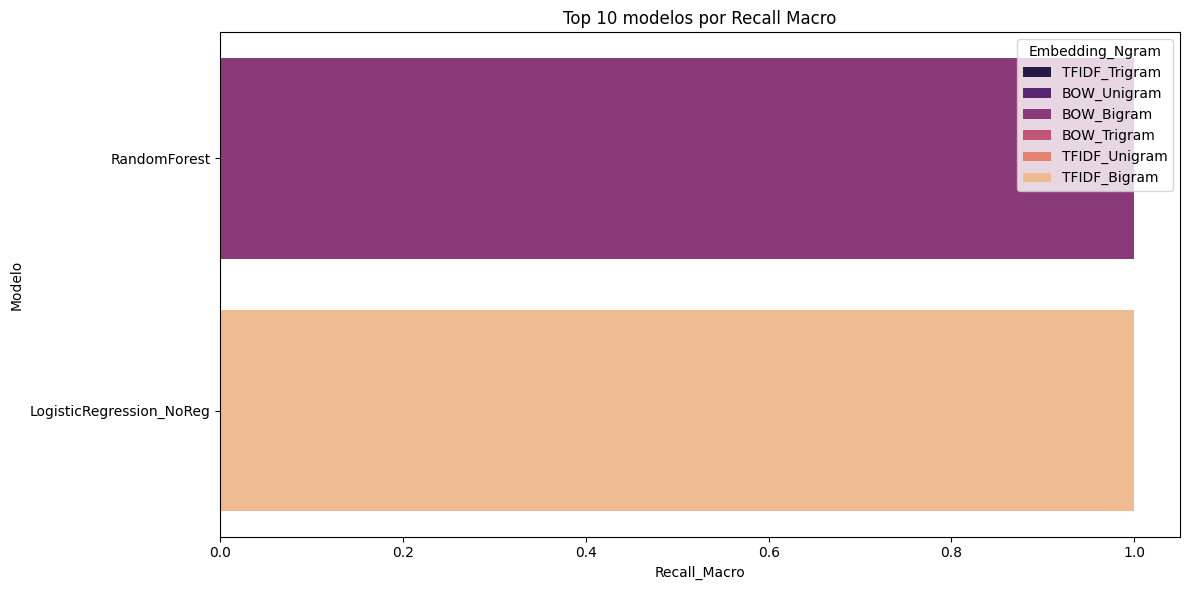

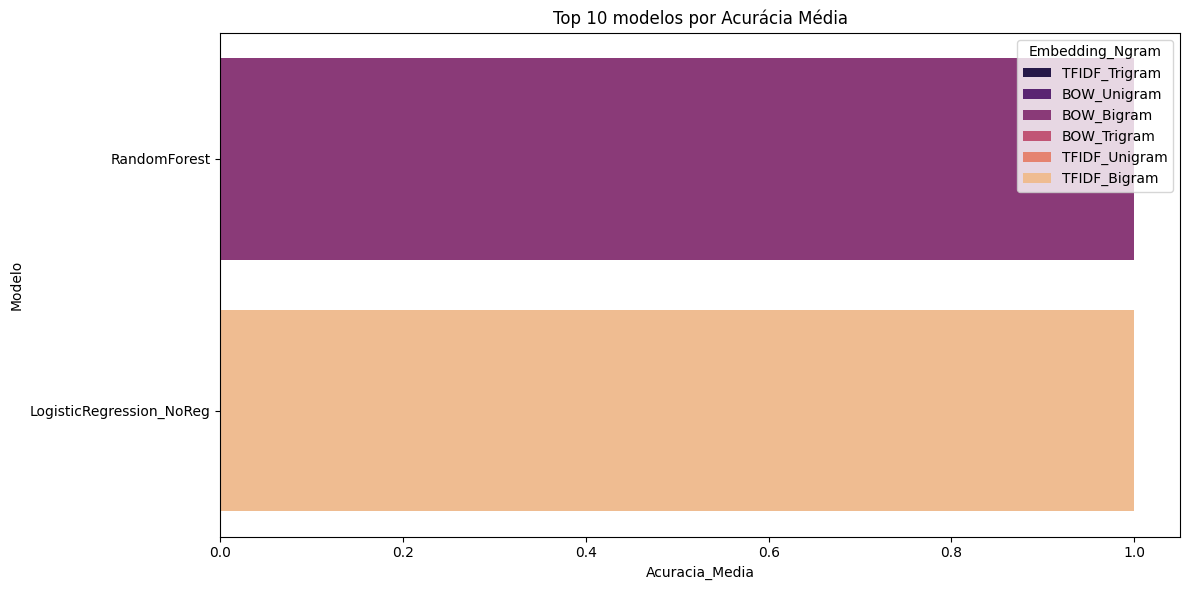

In [17]:
# 📊 Célula 7: Gráficos de precisão, recall e acurácia
metricas = ['Precisao_Macro', 'Recall_Macro', 'Acuracia_Media']
titulos = ['Precisão Macro', 'Recall Macro', 'Acurácia Média']

for metrica, titulo in zip(metricas, titulos):
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=results_df_sorted.head(10),
        x=metrica,
        y='Modelo',
        hue='Embedding_Ngram',
        dodge=False,
        palette='magma'
    )
    plt.title(f'Top 10 modelos por {titulo}')
    plt.tight_layout()
    plt.show()

In [18]:
print("Melhor modelo")
results_df_sorted.head(1)

Melhor modelo


,Modelo,Normalizador,Preprocessamento,Embedding_Ngram,F1_Macro,Precisao_Macro,Recall_Macro,Acuracia_Media
0,RandomForest,MinMax,Com_Preprocessamento,TFIDF_Trigram,1.0,1.0,1.0,1.0
